*   Github Link - https://github.com/balina1234/Individual-Assignment-Machine-Learning-Tutorial.git
*   Dataset Link - https://www.kaggle.com/datasets/nadyana/flowers




Flower Image Classification using CNN and Transfer Learning with EfficientNetB0 (Fine-Tuning)

*   This tutorial demonstrates an end-to-end image classification pipeline using deep learning techniques. A baseline Convolutional Neural Network (CNN) is implemented and compared with a transfer learning approach using EfficientNetB0. The workflow includes dataset cleaning, preprocessing, exploratory data analysis, model training, evaluation, and fine-tuning. The objective is to show how transfer learning improves performance over a model trained from scratch.



INSTALL & IMPORTS

In [2]:
# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

DATASET

In [3]:
import kagglehub

# Download flowers dataset from Kaggle
path = kagglehub.dataset_download("nadyana/flowers")

# Display download path
print("Downloaded path:", path)

# Define dataset directory (contains class folders)
DATASET_PATH = os.path.join(path, "flowers")

# List available classes
print("Classes:", os.listdir(DATASET_PATH))

Using Colab cache for faster access to the 'flowers' dataset.
Downloaded path: /kaggle/input/flowers
Classes: ['bellflower', 'dandelion', 'daisy', 'sunflower', 'tulip', 'lotus', 'rose']


DATA CLEANING

In [4]:
# Import required libraries for file handling and image validation
import os
from PIL import Image

# Function to clean dataset by removing invalid files
def clean_dataset(dataset_path):
    removed = 0  # Counter for removed files

    # Loop through each class folder
    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)

        # Skip if not a directory
        if not os.path.isdir(class_path):
            continue

        # Loop through each file in the class folder
        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)

            # Remove unsupported file formats
            if not file.lower().endswith((".jpg", ".jpeg", ".png")):
                os.remove(file_path)
                removed += 1
                continue

            # Check if image is corrupted or unreadable
            try:
                img = Image.open(file_path)
                img.verify()  # Verify image integrity
            except:
                os.remove(file_path)
                removed += 1

    # Display number of removed files
    print(f"Removed {removed} invalid files")

# Execute dataset cleaning
clean_dataset(DATASET_PATH)

Removed 0 invalid files


LOAD DATA

In [5]:
# Define image size and batch size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training dataset (80% of data)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,     # Split dataset into train and validation
    subset="training",
    seed=42,                 # Ensures reproducibility
    image_size=IMG_SIZE,     # Resize all images to fixed size
    batch_size=BATCH_SIZE    # Number of images per batch
)

# Load validation dataset (20% of data)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract class names and number of classes
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

# Display detected classes
print("Detected classes:", CLASS_NAMES)

# Ignore corrupted or problematic images during loading
train_ds = train_ds.ignore_errors()
val_ds = val_ds.ignore_errors()

Found 11200 files belonging to 7 classes.
Using 8960 files for training.
Found 11200 files belonging to 7 classes.
Using 2240 files for validation.
Detected classes: ['bellflower', 'daisy', 'dandelion', 'lotus', 'rose', 'sunflower', 'tulip']


Exploratory Data Analysis(EDA)

DISPLAY SAMPLE IMAGES

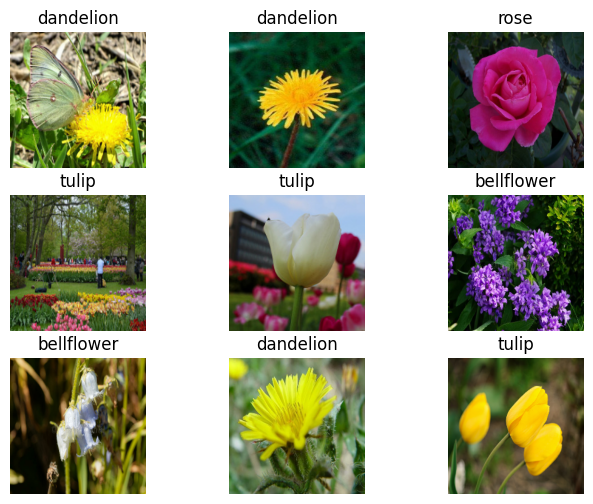

In [6]:
# Create figure for displaying sample images
plt.figure(figsize=(8,6))

# Take one batch from training dataset
for images, labels in train_ds.take(1):
    for i in range(9):  # Display first 9 images

        # Create subplot grid (3x3)
        ax = plt.subplot(3,3,i+1)

        # Convert image to uint8 to match display format
        plt.imshow(images[i].numpy().astype("uint8"))

        # Show corresponding class label
        plt.title(CLASS_NAMES[labels[i]])

        # Hide axis for cleaner visualization
        plt.axis("off")

# Display all images
plt.show()

IMAGE COUNT PER CLASS

In [6]:
import pandas as pd

# Dictionary to store image count per class
counts = {}

# Loop through each class folder
for folder in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, folder)

    # Ensure it is a valid directory
    if os.path.isdir(class_path):
        # Count number of images in each class
        counts[folder] = len(os.listdir(class_path))

# Convert dictionary to DataFrame
df = pd.DataFrame.from_dict(counts, orient='index', columns=['Image_Count'])

# Sort classes by number of images (descending)
df = df.sort_values(by="Image_Count", ascending=False)

# Display class distribution
print(df)

            Image_Count
rose               1600
sunflower          1600
tulip              1600
daisy              1600
bellflower         1600
dandelion          1600
lotus              1600


BAR CHART

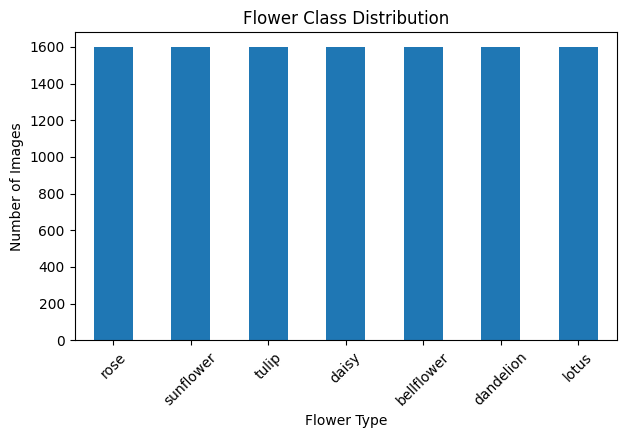

In [7]:
# Plot class distribution as bar chart
df.plot(kind='bar', figsize=(7,4), legend=False)

# Add labels and title
plt.title("Flower Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Flower Type")

# Rotate labels for better readability
plt.xticks(rotation=45)

# Display plot
plt.show()

PIE CHART

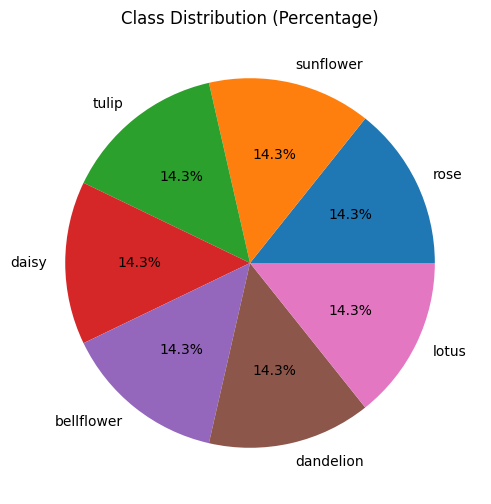

In [8]:
# Plot class distribution as pie chart
plt.figure(figsize=(6,6))
plt.pie(df["Image_Count"], labels=df.index, autopct='%1.1f%%')

# Add title
plt.title("Class Distribution (Percentage)")

# Display plot
plt.show()

IMAGE SIZE ANALYSIS

In [9]:
# Import image processing library
from PIL import Image

# Lists to store image dimensions
widths = []
heights = []

# Loop through dataset folders
for folder in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(class_path):
        # Sample first 50 images per class (for speed)
        for file in os.listdir(class_path)[:50]:
            try:
                # Open image and get size
                img = Image.open(os.path.join(class_path, file))
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                continue  # Skip invalid images

# Print average image dimensions
print("Average Width:", sum(widths)//len(widths))
print("Average Height:", sum(heights)//len(heights))

Average Width: 433
Average Height: 380


NORMALISATION



*   Images have pixel values in the range 0–255, but neural networks perform better when inputs are scaled to 0–1. Normalization improves training stability, speeds up convergence, and enhances overall model performance. It is mainly applied to the baseline CNN since it is trained from scratch.



In [10]:
# Normalize pixel values from [0,255] → [0,1]
normalization = layers.Rescaling(1./255)

# Apply normalization to training dataset
train_ds_cnn = train_ds.map(lambda x, y: (normalization(x), y))

# Apply normalization to validation dataset
val_ds_cnn = val_ds.map(lambda x, y: (normalization(x), y))

# BASELINE CNN - Model Build
The baseline CNN model is a simple convolutional neural network designed for image classification. It uses multiple convolution and pooling layers to extract spatial features, followed by dense layers for learning patterns and making predictions. Dropout is applied to reduce overfitting, and a softmax layer is used to output class probabilities. This model serves as a reference for comparing performance with more advanced models.

In [11]:
# Define baseline CNN model
baseline_model = models.Sequential([
    tf.keras.Input(shape=(224,224,3)),  # Input layer

    # First convolution block
    layers.Conv2D(32, 3, activation="relu"),  # Feature extraction
    layers.MaxPooling2D(),                   # Downsampling

    # Second convolution block
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    # Third convolution block
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    # Flatten feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Dropout to reduce overfitting
    layers.Dropout(0.5),

    # Output layer for classification
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
baseline_model.compile(
    optimizer="adam",                         # Optimization algorithm
    loss="sparse_categorical_crossentropy",   # Loss for multi-class classification
    metrics=["accuracy"]                      # Evaluation metric
)

# Display model architecture
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

TRAIN BASELINE

In [12]:
# Train baseline CNN model on normalized dataset
baseline_history = baseline_model.fit(
    train_ds_cnn,              # Training data
    validation_data=val_ds_cnn, # Validation data for evaluation
    epochs=10                  # Number of training iterations
)

Epoch 1/10
    275/Unknown 32s 86ms/step - accuracy: 0.3893 - loss: 1.6198

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


275/275 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.4836 - loss: 1.4025 - val_accuracy: 0.6357 - val_loss: 1.0928
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 31s 111ms/step - accuracy: 0.6077 - loss: 1.1056 - val_accuracy: 0.6688 - val_loss: 0.9524
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 30s 108ms/step - accuracy: 0.6851 - loss: 0.9010 - val_accuracy: 0.7055 - val_loss: 0.8834
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 42s 153ms/step - accuracy: 0.7532 - loss: 0.7148 - val_accuracy: 0.7206 - val_loss: 0.8419
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 41s 148ms/step - accuracy: 0.8152 - loss: 0.5405 - val_accuracy: 0.7552 - val_loss: 0.8290
Epoch 6/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 30s 109ms/step - accuracy: 0.8632 - loss: 0.4082 - val_accuracy: 0.7579 - val_loss: 0.7461
Epoch 7/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 46s 167ms/step - accuracy: 0.8902 - loss: 0.3227 - val_accuracy: 0.7666 - val_loss: 0.9368
Epoch 8/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 30s 108ms/step - accuracy: 0.9077 - loss: 0.2613 - val

Accuracy Plot

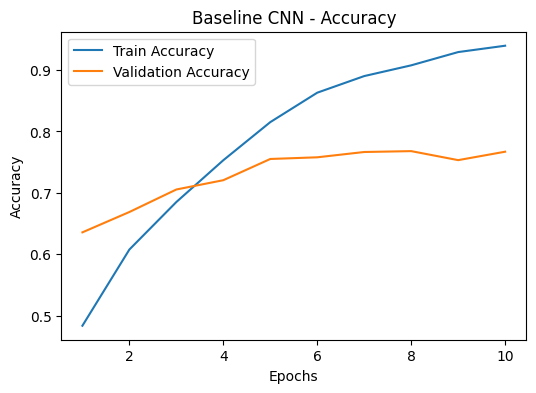

In [13]:
# Extract accuracy metrics
acc = baseline_history.history['accuracy']
val_acc = baseline_history.history['val_accuracy']

# Define epochs
epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(6,4))
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

# Labels and title
plt.title("Baseline CNN - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Show plot
plt.show()

Loss Plot

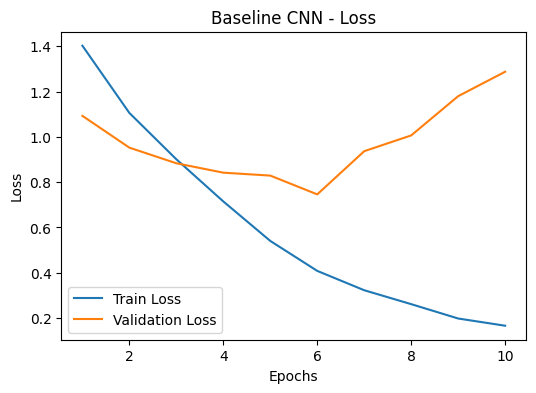

In [14]:
# Extract loss metrics
loss = baseline_history.history['loss']
val_loss = baseline_history.history['val_loss']

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

# Labels and title
plt.title("Baseline CNN - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Show plot
plt.show()

Classification Report

In [15]:
# Import evaluation metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Store true and predicted labels
y_true = []
y_pred = []

# Generate predictions on validation data
for images, labels in val_ds:
    preds = baseline_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)  # Convert probabilities to class labels

    y_true.extend(labels.numpy())     # True labels
    y_pred.extend(preds)              # Predicted labels

# Calculate evaluation metrics
baseline_acc = accuracy_score(y_true, y_pred)
baseline_precision = precision_score(y_true, y_pred, average='weighted')
baseline_recall = recall_score(y_true, y_pred, average='weighted')
baseline_f1 = f1_score(y_true, y_pred, average='weighted')

# Print classification report
print("\n===== Classification Report =====\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


===== Classification Report =====

              precision    recall  f1-score   support

  bellflower       0.90      0.82      0.86       293
       daisy       0.72      0.61      0.66       300
   dandelion       0.79      0.45      0.57       290
       lotus       0.72      0.74      0.73       304
        rose       0.54      0.70      0.61       326
   sunflower       0.62      0.91      0.74       294
       tulip       0.74      0.62      0.67       305

    accuracy                           0.69      2112
   macro avg       0.72      0.69      0.69      2112
weighted avg       0.72      0.69      0.69      2112



Confusion Matrix

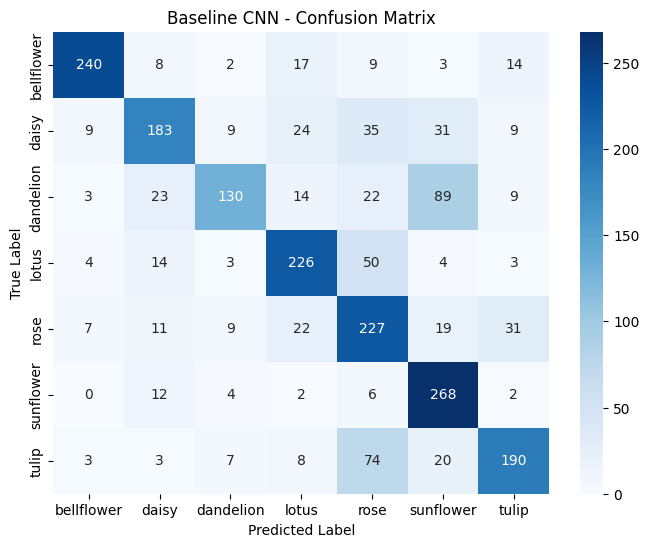

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN - Confusion Matrix")

# Show plot
plt.show()

EfficientNetB0 (Transfer Learning)

*   EfficientNetB0 is a pre-trained deep learning model used for transfer learning. It extracts rich features from images using knowledge learned from the ImageNet dataset. Preprocessing ensures inputs match the model’s expected format, while data augmentation improves generalization by creating variations of images. The base model is frozen to retain learned features, and custom layers are added for classification. This approach improves performance while reducing training time.



APPLY EfficientNet preprocessing

In [17]:
# Apply EfficientNet-specific preprocessing
from tensorflow.keras.applications.efficientnet import preprocess_input

train_ds_eff = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_eff = val_ds.map(lambda x, y: (preprocess_input(x), y))


Data Augmentation

In [18]:
# Apply random transformations to improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # Flip images horizontally
    layers.RandomRotation(0.2),        # Random rotation
    layers.RandomZoom(0.2),            # Random zoom
])


EfficientNetB0 - Build Model

In [19]:
# Load pre-trained EfficientNetB0 model
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',           # Use pre-trained weights
    include_top=False,            # Remove original classifier
    input_shape=(224,224,3)
)

# Freeze base model layers
base_model.trainable = False

# Define input layer
inputs = tf.keras.Input(shape=(224,224,3))

# Apply data augmentation
x = data_augmentation(inputs)

# Extract features using EfficientNet
x = base_model(x, training=False)

# Add custom classification head
x = layers.GlobalAveragePooling2D()(x)  # Reduce dimensions
x = layers.BatchNormalization()(x)      # Stabilize training
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Output layer
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create final model
efficient_model = models.Model(inputs, outputs)

# Compile model
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


TRAIN FROZEN MODEL

In [20]:
# Train EfficientNet model
history_eff = efficient_model.fit(
    train_ds_eff,            # Training data with preprocessing
    validation_data=val_ds_eff,  # Validation data
    epochs=10                # Number of epochs
)

Epoch 1/10
    275/Unknown 43s 96ms/step - accuracy: 0.6158 - loss: 1.1910

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


275/275 ━━━━━━━━━━━━━━━━━━━━ 53s 132ms/step - accuracy: 0.7351 - loss: 0.8017 - val_accuracy: 0.9249 - val_loss: 0.2485
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.8509 - loss: 0.4426 - val_accuracy: 0.9318 - val_loss: 0.2058
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.8764 - loss: 0.3664 - val_accuracy: 0.9403 - val_loss: 0.1797
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 33s 120ms/step - accuracy: 0.8886 - loss: 0.3321 - val_accuracy: 0.9437 - val_loss: 0.1715
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.8991 - loss: 0.2957 - val_accuracy: 0.9498 - val_loss: 0.1541
Epoch 6/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 33s 120ms/step - accuracy: 0.9045 - loss: 0.2778 - val_accuracy: 0.9482 - val_loss: 0.1549
Epoch 7/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 34s 125ms/step - accuracy: 0.9108 - loss: 0.2667 - val_accuracy: 0.9470 - val_loss: 0.1560
Epoch 8/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.9177 - loss: 0.2428 - val

Accuracy Plot - EfficientNetB0

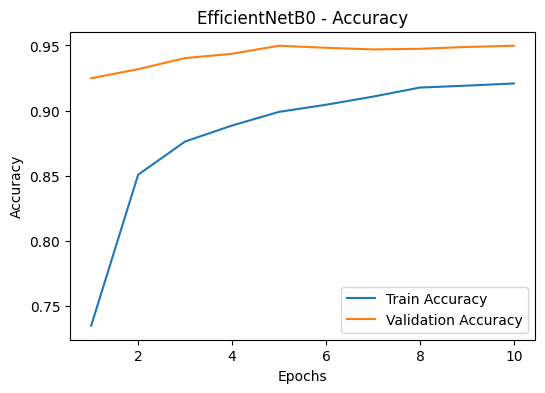

In [21]:
# Extract accuracy metrics
acc = history_eff.history['accuracy']
val_acc = history_eff.history['val_accuracy']

# Define epochs
epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(6,4))
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

# Labels and title
plt.title("EfficientNetB0 - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Show plot
plt.show()

Loss Plot - EfficientNetB0

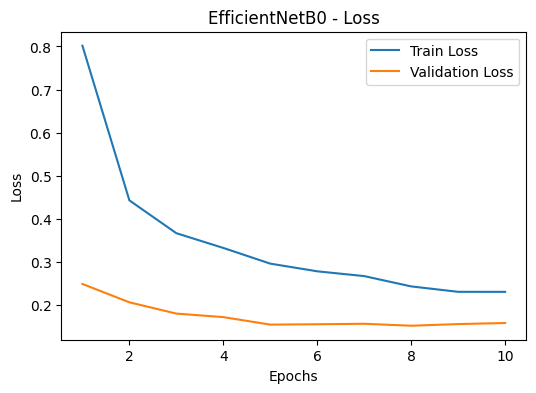

In [22]:
# Extract loss metrics
loss = history_eff.history['loss']
val_loss = history_eff.history['val_loss']

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

# Labels and title
plt.title("EfficientNetB0 - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Show plot
plt.show()

Classification Report

In [23]:
# Store true and predicted labels
y_true_eff = []
y_pred_eff = []

# Generate predictions on validation data
for images, labels in val_ds_eff:
    preds = efficient_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)  # Convert to class labels

    y_true_eff.extend(labels.numpy())  # True labels
    y_pred_eff.extend(preds)           # Predicted labels

# Calculate evaluation metrics
efficient_acc = accuracy_score(y_true_eff, y_pred_eff)
efficient_precision = precision_score(y_true_eff, y_pred_eff, average='weighted')
efficient_recall = recall_score(y_true_eff, y_pred_eff, average='weighted')
efficient_f1 = f1_score(y_true_eff, y_pred_eff, average='weighted')

# Print classification report
print("\n===== efficient Classification Report =====\n")
print(classification_report(y_true_eff, y_pred_eff, target_names=CLASS_NAMES))


===== efficient Classification Report =====

              precision    recall  f1-score   support

  bellflower       0.98      0.96      0.97       297
       daisy       0.95      0.94      0.95       300
   dandelion       0.97      0.95      0.96       290
       lotus       0.97      0.96      0.97       303
        rose       0.95      0.94      0.94       325
   sunflower       0.96      0.95      0.95       294
       tulip       0.90      0.95      0.92       303

    accuracy                           0.95      2112
   macro avg       0.95      0.95      0.95      2112
weighted avg       0.95      0.95      0.95      2112



Confusion Matrix

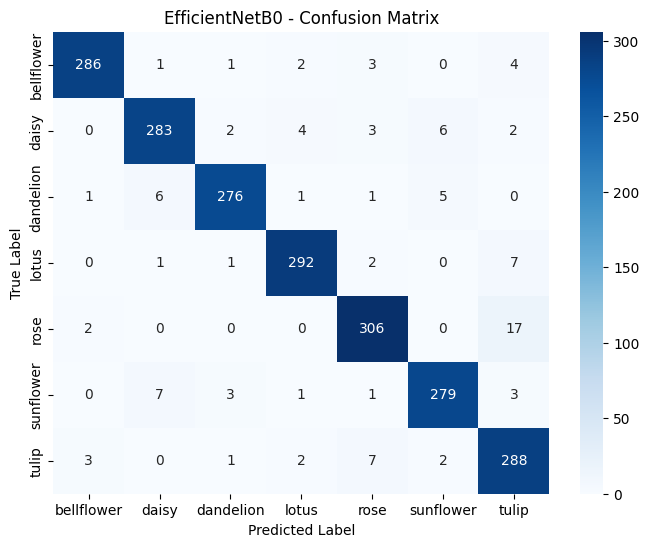

In [24]:
# Compute confusion matrix
cm = confusion_matrix(y_true_eff, y_pred_eff)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 - Confusion Matrix")

# Show plot
plt.show()

Fine-Tuned EfficientNet



*   Fine-tuning improves model performance by allowing the top layers of EfficientNet to adapt to the new dataset. Instead of training from scratch, only the last few layers are unfrozen while earlier layers remain fixed. A low learning rate is used to make small updates without damaging the pre-trained weights, resulting in better accuracy and generalization.



Unfreeze Top Layers

In [25]:
# Unfreeze last 50 layers of EfficientNet for fine-tuning
for layer in base_model.layers[-50:]:
    layer.trainable = True


Recompile

In [26]:
# Recompile model with low learning rate
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Small LR for stable updates
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Fine-Tuned Model

In [27]:
# Train fine-tuned EfficientNet model
history_eff_ft = efficient_model.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=10
)

Epoch 1/10
    275/Unknown 52s 119ms/step - accuracy: 0.8375 - loss: 0.4748

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


275/275 ━━━━━━━━━━━━━━━━━━━━ 62s 154ms/step - accuracy: 0.8543 - loss: 0.4363 - val_accuracy: 0.9384 - val_loss: 0.1974
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 39s 141ms/step - accuracy: 0.8817 - loss: 0.3554 - val_accuracy: 0.9440 - val_loss: 0.1797
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 42s 153ms/step - accuracy: 0.8948 - loss: 0.3027 - val_accuracy: 0.9484 - val_loss: 0.1690
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 39s 141ms/step - accuracy: 0.9049 - loss: 0.2864 - val_accuracy: 0.9512 - val_loss: 0.1625
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 40s 145ms/step - accuracy: 0.9126 - loss: 0.2580 - val_accuracy: 0.9545 - val_loss: 0.1544
Epoch 6/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 39s 141ms/step - accuracy: 0.9174 - loss: 0.2364 - val_accuracy: 0.9550 - val_loss: 0.1497
Epoch 7/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step - accuracy: 0.9228 - loss: 0.2333 - val_accuracy: 0.9593 - val_loss: 0.1438
Epoch 8/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 39s 141ms/step - accuracy: 0.9282 - loss: 0.2113 - val

Accuracy Plot (Fine-Tuned)

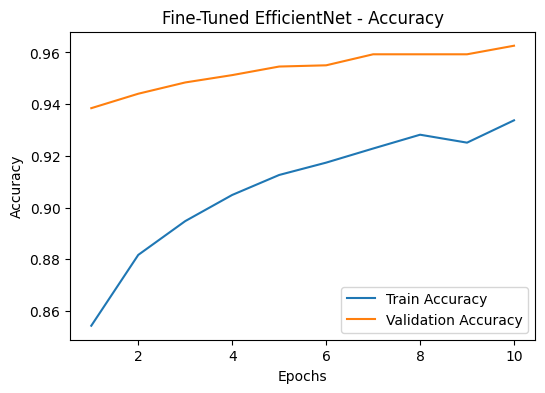

In [28]:
# Accuracy Plot (Fine-Tuned)
acc = history_eff_ft.history['accuracy']
val_acc = history_eff_ft.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title("Fine-Tuned EfficientNet - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Loss Plot (Fine-Tuned)

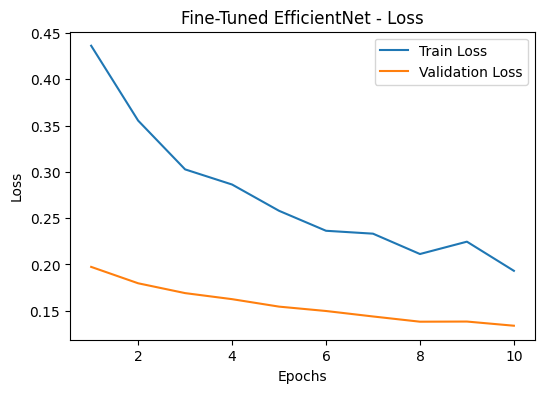

In [29]:
# Loss Plot (Fine-Tuned)
loss = history_eff_ft.history['loss']
val_loss = history_eff_ft.history['val_loss']

plt.figure(figsize=(6,4))
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title("Fine-Tuned EfficientNet - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Evaluation (Fine-Tuned)

In [30]:
# Store true and predicted labels
y_true_ft = []
y_pred_ft = []

# Generate predictions
for images, labels in val_ds_eff:
    preds = efficient_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)  # Convert to class labels

    y_true_ft.extend(labels.numpy())  # True labels
    y_pred_ft.extend(preds)           # Predicted labels

# Calculate metrics
ft_acc = accuracy_score(y_true_ft, y_pred_ft)
ft_precision = precision_score(y_true_ft, y_pred_ft, average='weighted')
ft_recall = recall_score(y_true_ft, y_pred_ft, average='weighted')
ft_f1 = f1_score(y_true_ft, y_pred_ft, average='weighted')

# Print report
print("Fine-Tuned EfficientNet Report")
print(classification_report(y_true_ft, y_pred_ft, target_names=CLASS_NAMES))

Fine-Tuned EfficientNet Report
              precision    recall  f1-score   support

  bellflower       0.97      0.98      0.98       290
       daisy       0.97      0.97      0.97       297
   dandelion       0.97      0.96      0.96       286
       lotus       0.97      0.97      0.97       303
        rose       0.95      0.96      0.96       330
   sunflower       0.98      0.95      0.96       296
       tulip       0.94      0.95      0.95       310

    accuracy                           0.96      2112
   macro avg       0.96      0.96      0.96      2112
weighted avg       0.96      0.96      0.96      2112



Confusion Matrix (Fine-Tuned)

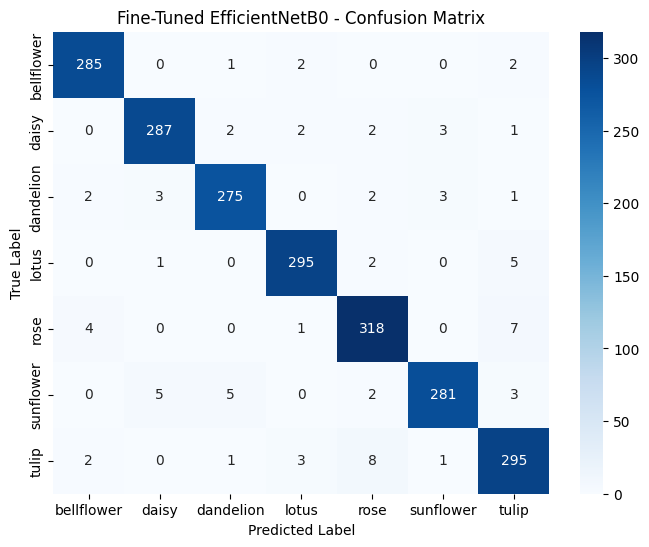

In [31]:
# Compute confusion matrix
cm = confusion_matrix(y_true_ft, y_pred_ft)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fine-Tuned EfficientNetB0 - Confusion Matrix")

# Show plot
plt.show()

Comparison Table

In [32]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Baseline CNN", "EfficientNet", "Fine-Tuned EfficientNet"],
    "Accuracy": [baseline_acc, efficient_acc, ft_acc],
    "Precision": [baseline_precision, efficient_precision, ft_precision],
    "Recall": [baseline_recall, efficient_recall, ft_recall],
    "F1-Score": [baseline_f1, efficient_f1, ft_f1]
})

print("\nModel Comparison\n")
print(comparison_df)


Model Comparison

                     Model  Accuracy  Precision    Recall  F1-Score
0             Baseline CNN  0.693182   0.715430  0.693182  0.690575
1             EfficientNet  0.951705   0.952297  0.951705  0.951861
2  Fine-Tuned EfficientNet  0.964015   0.964123  0.964015  0.964027


Predictions Function

In [33]:
# Function to visualize model predictions on sample images
def show_predictions(model, dataset, title, class_names):

    # Create figure for displaying predictions
    plt.figure(figsize=(10,10))

    # Take one batch from dataset
    for images, labels in dataset.take(1):

        # Generate predictions
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)  # Convert probabilities to class labels

        # Loop through first 9 images
        for i in range(9):
            ax = plt.subplot(3,3,i+1)

            # Get image tensor
            img = images[i].numpy()

            # Normalize image back to 0–1 range for display
            img = (img - img.min()) / (img.max() - img.min())

            # Display image
            plt.imshow(img)

            # Get true and predicted labels
            true_label = class_names[labels[i]]
            pred_label = class_names[preds[i]]

            # Set title color (green = correct, red = incorrect)
            color = "green" if true_label == pred_label else "red"

            # Show labels on image
            plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
            plt.axis("off")

    # Add overall title
    plt.suptitle(title)

    # Adjust layout
    plt.tight_layout()

    # Display results
    plt.show()

Baseline CNN - Predictions

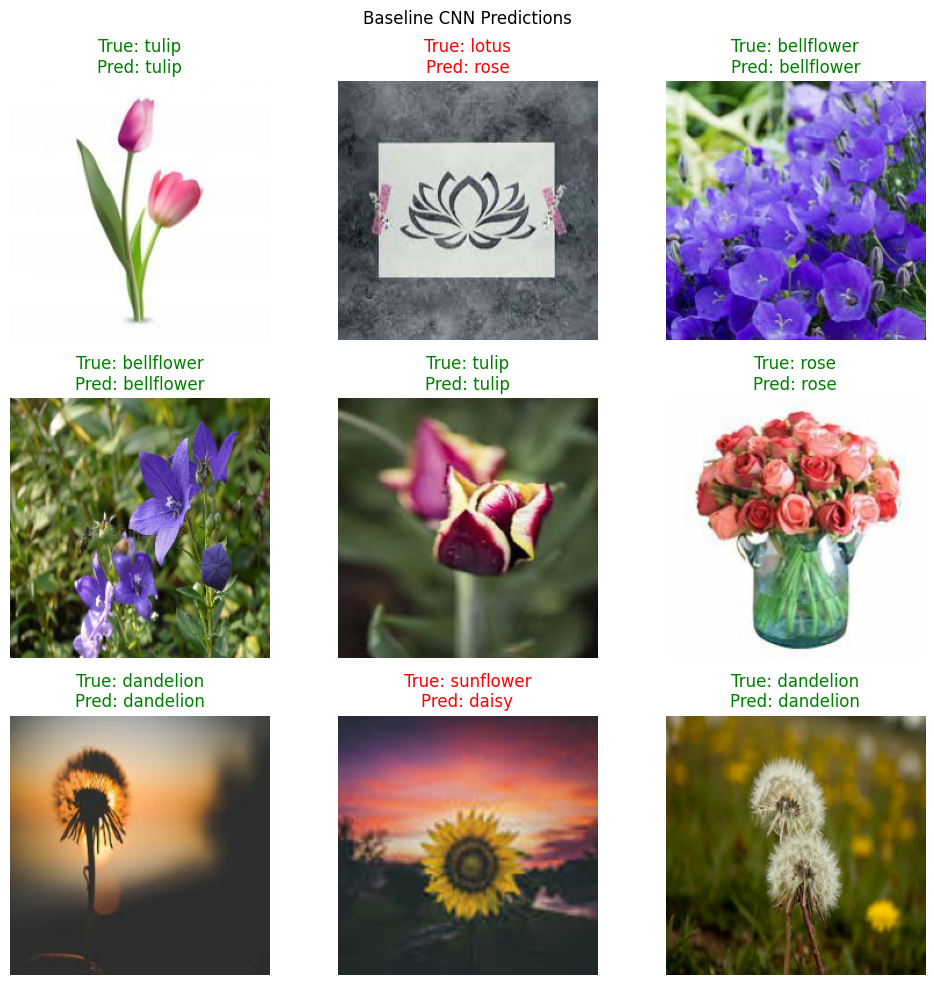

In [34]:
# Visualize predictions from baseline CNN
show_predictions(
    baseline_model,
    val_ds_cnn,                     # Validation dataset
    title="Baseline CNN Predictions",
    class_names=CLASS_NAMES
)

EfficientNet - Predictions



*   EfficientNet uses the same model instance for both frozen and fine-tuned predictions.




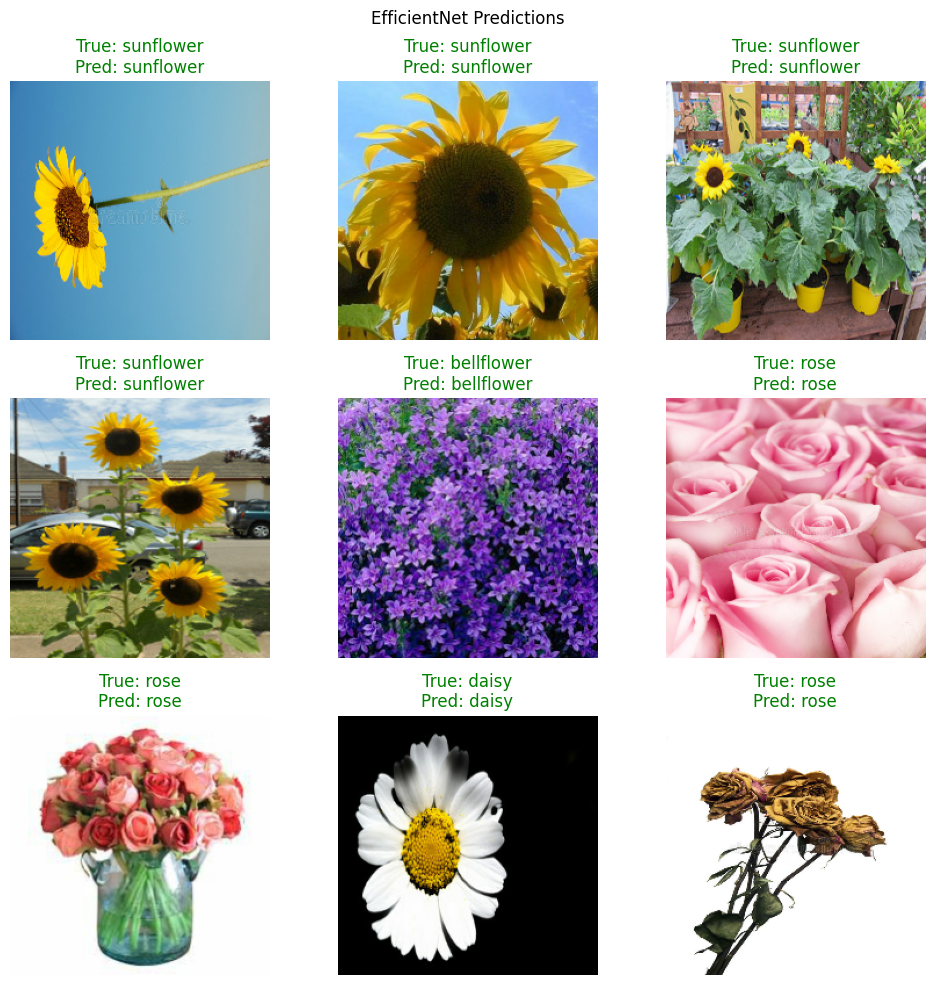

In [35]:
# Visualize predictions from EfficientNet model
show_predictions(
    efficient_model,
    val_ds,                         # Validation dataset
    title="EfficientNet Predictions",
    class_names=CLASS_NAMES
)